In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import logging
import sys

from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

import os
import time

from collections.abc import Callable
from dataclasses import asdict
from pathlib import Path
from typing import TYPE_CHECKING, Any

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn

from torch.amp.autocast_mode import autocast
from torch.amp.grad_scaler import GradScaler
from torch.optim import Adam
from tqdm import tqdm

from experiments.plotting import (
    _plot_SRE_distribution,
    plot_training_curves,
    view_correlation,
)
from GNN.parameter_search.helpers import objective_GNN, objective_NN
from GNN.physics_aware_NN import GNN, NN, Regressor
from GNN.training.datasets import build_loaders, build_loaders_NN
from GNN.training.train import build_loss, train_model
from GNN.training.train_config import TrainConfig
from GNN.training.utils import (
    collect_dataset_indices,
    collect_dataset_paths,
    evaluate_loss,
    evaluate_r2,
    to_scalar,
    unpack_supervised_batch,
)
from scripts import (
    generate_dataset,
    optuna_search,
    predictions,
    training,
)
from scripts.train_model import PARAMS
from src.utils import configure_logger

if TYPE_CHECKING:
    from torch_geometric.loader import DataLoader

from GNN.training.train import build_loss, TrainHistory, _run_train_epoch
from GNN.training.runners import _resolve_model_save_path

In [11]:
logger = logging.getLogger(__name__)
configure_logger(logging.INFO, logging.INFO)

True

In [12]:
def train_and_predict(
    model_type,
    family,
    target,
    target_variant,
    epochs=25,
    lr=0.001,
    loss_type = "huber",
    batch_size = 32,
    training_mode = "per_family",
    training_data_dir="../outputs/data/datasets_SRE",
    split="target",
    plot_qubits=10,
    plot_layers=80,
):
    model_save_path=f"../notebooks/final/models/{family}_model_{model_type}_{training_mode}_{target_variant}.pt"
    save_fig_path="../notebooks/final/figures/training_curves/training_curves"
    training(
        epochs=epochs,
        lr=lr,
        loss_type=loss_type,
        batch_size=batch_size,
        training_mode=training_mode,
        family=family,
        target=target,
        target_variant=target_variant,
        model_type=model_type,
        model_hparams=None,
        train_hparams=None,
        training_data_dir=training_data_dir,
        split=split,
        model_save_path=model_save_path,
        save_fig_path = save_fig_path,
        show_progress=True,
        show_val_progress=False,
        log_every_n_batches=10,
        heartbeat_secs=60.0,
        epoch_time_warning_secs=600.0,
    )

    training_scope = "family" if training_mode == "per_family" else "global"
    batch_size = PARAMS.get(family, {}).get("batch_size", batch_size)
    predictions(
        model_path=model_save_path,
        model_kind=model_type,
        training_scope=training_scope,
        target_variant=target_variant,
        loss_type=loss_type,
        model_family=family,
        dataset_root=training_data_dir,
        dataset_family=family,
        output_root="../notebooks/final/predictions/",
        batch_size=batch_size,
        global_feature_variant="binned",
        node_feature_backend_variant=None,
        plot_n_layers=plot_layers,
        plot_n_qubits=plot_qubits,
        split_by_family=True,
        show_progress=True,
    )

In [13]:
def plot_predictions(family, target_variant, pred_file_path=f"../notebooks/final/predictions//family/gnn_predictions", plot_qubits=10, plot_layers=80):
    df = pd.read_csv(pred_file_path+f"_{family}.csv")
    cols_to_fix = ["n_qubits", "n_layers", "seed"]

    for col in cols_to_fix:
        df[col] = df[col].apply(to_scalar).astype(int)

    new_df = df[(df["n_qubits"] == plot_qubits) & (df["n_layers"] == plot_layers)]

    nq=plot_qubits
    nl=plot_layers

    if target_variant == "sre_density":
        new_df["target_sre"] = new_df["target_sre"] * nq

    # print(new_df["target_sre"].describe())
    # print(new_df["predicted_sre"].describe())

    # df = df[(df["n_qubits"] == plot_qubits)]

    view_correlation(
        new_df,
        nq=plot_qubits,
        nl=plot_layers,
        col_x="target_sre",
        col_y="predicted_sre",
    )
    # df = df[(df["n_qubits"] == plot_qubits) & (df["n_layers"] == plot_layers)]
    plt.figure(figsize=(8, 6))
    plt.scatter(new_df["target_sre"], new_df["predicted_sre"], alpha=0.7)
    plt.plot([new_df["target_sre"].min(), new_df["target_sre"].max()], [new_df["target_sre"].min(), new_df["target_sre"].max()], "r--")  # y=x line
    plt.xlabel("True SRE")
    plt.ylabel("Predicted SRE")
    plt.title(f"True vs Predicted SRE for {family} Family (GNN Model)")

## Running on SRE density 

In [14]:
model_type="gnn"
epochs = 30
lr = 1.5131621801102364e-05
loss_type = "huber"   # "mse" | "huber"
batch_size = 16
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
training_data_dir = "../outputs/data/datasets_SRE"
target_variant = "sre_density"  # "sre" | "sre_density" | "log_sre" | "sqrt_sre"
model_save_path = f"../notebooks/outputs/models/final/{family}_model_{model_type}_{training_mode}_{target_variant}.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
training_scope = "family" if training_mode == "per_family" else "global"
plot_qubits = 6
plot_layers = 100

split = "target"  # "target" | "family"

In [15]:
train_and_predict(
    model_type=model_type,
    family=family,
    target=target,
    target_variant=target_variant,
    epochs=epochs,
)

2026-07-02 15:44:46,360 - GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=random | loss_type=huber
2026-07-02 15:44:46,361 - GNN.training.runners - INFO - Training configuration done.
2026-07-02 15:44:46,361 - GNN.training.runners - INFO - Collecting data paths...
2026-07-02 15:44:46,362 - GNN.training.runners - INFO - Found 1 data paths.
2026-07-02 15:44:46,363 - GNN.training.runners - INFO - Data paths collected.
2026-07-02 15:44:46,363 - GNN.training.runners - INFO - Building loaders and model for model_type=gnn...
2026-07-02 15:47:49,050 - GNN.training.runners - INFO - Loaders built | train_loader=25704 graphs | val_loader=2856 graphs | test_loader=7140 graphs
2026-07-02 15:47:49,100 - GNN.training.runners - INFO - Loaders and model built.
2026-07-02 15:47:49,100 - GNN.training.runners - INFO - Starting training...
2026-07-02 15:47:49,100 - GNN.training.train - INFO - Using device: cuda
2026-07-02 15:47:49,312 - GNN.training.trai

Epoch 1/30:  31%|███▏      | 63/201 [01:00<02:15,  1.02it/s, loss=0.0153, graphs=8192]

2026-07-02 15:48:49,848 - GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 64/201 | loss 0.015251 | elapsed 60.5s | graphs 8192


Epoch 1/30:  65%|██████▌   | 131/201 [02:00<00:59,  1.19it/s, loss=0.0092, graphs=16896]

2026-07-02 15:49:50,315 - GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 132/201 | loss 0.009155 | elapsed 121.0s | graphs 16896


...

2026-07-02 17:33:56,554 - GNN.training.train - INFO - [Heartbeat] Epoch 30 batch 123/201 | loss 0.000982 | elapsed 121.5s | graphs 15744


Epoch 30/30:  91%|█████████ | 182/201 [03:01<00:19,  1.04s/it, loss=0.0010, graphs=23424]

2026-07-02 17:34:56,818 - GNN.training.train - INFO - [Heartbeat] Epoch 30 batch 183/201 | loss 0.000991 | elapsed 181.8s | graphs 23424


2026-07-02 17:35:14,394 - GNN.training.train - INFO - Training complete (199.4s) | running validation...


2026-07-02 17:35:35,716 - GNN.training.train - INFO - Losses | train 0.000993 | val 0.000965 | lr 1.23e-04 | time train=199.4s val=21.3s total=220.7s
2026-07-02 17:40:55,865 - GNN.training.runners - INFO - Training complete.
2026-07-02 17:40:55,996 - experiments.plotting - INFO - Saved training curve plot to ..\notebooks\final\figures\training_curves\training_curves_gnn_huber_random_1.png
2026-07-02 17:40:56,008 - GNN.training.runners - INFO - Saved model checkpoint to ..\notebooks\final\models\random_model_gnn_per_family_sre_density.pt
2026-07-02 17:40:56,075 - scripts.train_model - INFO - Final test loss: 0.000914
2026-07-02 17:40:56,075 - scripts.train_model - INFO - Test R2 score: 0.9712
2026-07-02 17:40:56,076 - scripts.train_model - INFO - Validation R2 score: 0.9736
2026-07-02 17:40:56,077 - scripts.train_model - INFO - Training R2 score: 0.9732
2026-07-02 17:40:56,078 - scripts.predictions - INFO - Loading checkpoint: ../notebooks/final/models/random_model_gnn_per_family_sre_de

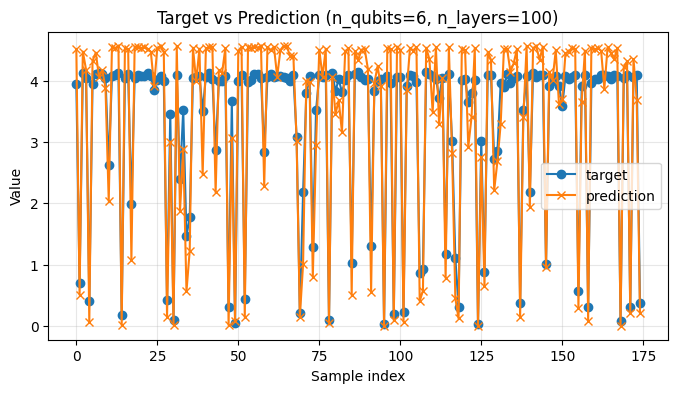

Pearson r = 0.9765


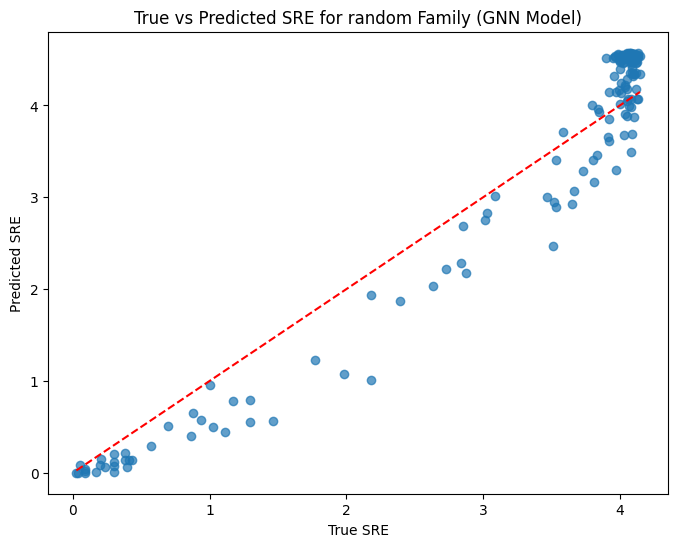

In [16]:
plot_predictions(
    family=family,
    target_variant=target_variant,
    pred_file_path=f"../notebooks/final/predictions/family/gnn_predictions",
    plot_qubits=plot_qubits,
    plot_layers=plot_layers,
)

In [18]:
model_type="gnn"
epochs = 30
lr = 1.5131621801102364e-05
loss_type = "huber"   # "mse" | "huber"
batch_size = 16
training_mode = "per_family"  # "global" | "per_family"
family = "clifford"  # required if training_mode == "per_family"
target = "sre"
training_data_dir = "../outputs/data/datasets_SRE"
target_variant = "sre_density"  # "sre" | "sre_density" | "log_sre" | "sqrt_sre"
model_save_path = f"../notebooks/outputs/models/final/{family}_model_{model_type}_{training_mode}_{target_variant}.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
training_scope = "family" if training_mode == "per_family" else "global"
plot_qubits = 6
plot_layers = 100

split = "target"  # "target" | "family"

In [ ]:
train_and_predict(
    model_type=model_type,
    family=family,
    target=target,
    target_variant=target_variant,
)

2026-07-02 18:43:08,077 - GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=clifford | loss_type=huber
2026-07-02 18:43:08,079 - GNN.training.runners - INFO - Training configuration done.
2026-07-02 18:43:08,079 - GNN.training.runners - INFO - Collecting data paths...
2026-07-02 18:43:08,081 - GNN.training.runners - INFO - Found 1 data paths.
2026-07-02 18:43:08,082 - GNN.training.runners - INFO - Data paths collected.
2026-07-02 18:43:08,082 - GNN.training.runners - INFO - Building loaders and model for model_type=gnn...
2026-07-02 18:43:39,467 - GNN.training.runners - INFO - Loaders built | train_loader=25704 graphs | val_loader=2856 graphs | test_loader=7140 graphs
2026-07-02 18:43:39,489 - GNN.training.runners - INFO - Loaders and model built.
2026-07-02 18:43:39,490 - GNN.training.runners - INFO - Starting training...
2026-07-02 18:43:39,492 - GNN.training.train - INFO - Using device: cuda
2026-07-02 18:43:39,506 - GNN.training.tr

2026-07-02 18:44:38,368 - GNN.training.train - INFO - Training complete (58.9s) | running validation...


2026-07-02 18:44:41,907 - GNN.training.train - INFO - Losses | train 0.023955 | val 0.008213 | lr 2.52e-05 | time train=58.9s val=3.5s total=62.4s
2026-07-02 18:44:41,912 - GNN.training.train - INFO - -------- EPOCH 002 --------


Epoch 2/25:  98%|█████████▊| 786/804 [01:00<00:01, 13.11it/s, loss=0.0071, graphs=25216]

2026-07-02 18:45:41,954 - GNN.training.train - INFO - [Heartbeat] Epoch 2 batch 788/804 | loss 0.007115 | elapsed 60.0s | graphs 25216


...

2026-07-02 18:47:53,564 - GNN.training.train - INFO - Training complete (61.2s) | running validation...


2026-07-02 18:47:57,315 - GNN.training.train - INFO - Losses | train 0.005439 | val 0.004598 | lr 2.52e-05 | time train=61.2s val=3.8s total=64.9s
2026-07-02 18:47:57,319 - GNN.training.train - INFO - -------- EPOCH 005 --------


Epoch 5/25:  98%|█████████▊| 788/804 [01:00<00:01, 13.60it/s, loss=0.0051, graphs=25280]

2026-07-02 18:48:57,358 - GNN.training.train - INFO - [Heartbeat] Epoch 5 batch 790/804 | loss 0.005114 | elapsed 60.0s | graphs 25280


2026-07-02 18:48:58,368 - GNN.training.train - INFO - Training complete (61.0s) | running validation...


In [ ]:
model_type="gnn"
epochs = 20
lr = 1.5131621801102364e-05
loss_type = "huber"   # "mse" | "huber"
batch_size = 16
training_mode = "per_family"  # "global" | "per_family"
family = "quansistor"  # required if training_mode == "per_family"
target = "sre"
training_data_dir = "../outputs/data/datasets_SRE"
target_variant = "sre_density"  # "sre" | "sre_density" | "log_sre" | "sqrt_sre"
model_save_path = f"../notebooks/outputs/models/final/{family}_model_{model_type}_{training_mode}_{target_variant}.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
training_scope = "family" if training_mode == "per_family" else "global"
plot_qubits = 6
plot_layers = 100

split = "target"  # "target" | "family"

In [ ]:
train_and_predict(
    model_type=model_type,
    family=family,
    target=target,
    target_variant=target_variant,
)

In [ ]:
model_type="gnn"
epochs = 20
lr = 1.5131621801102364e-05
loss_type = "huber"   # "mse" | "huber"
batch_size = 16
training_mode = "per_family"  # "global" | "per_family"
family = "haar"  # required if training_mode == "per_family"
target = "sre"
training_data_dir = "../outputs/data/datasets_SRE"
target_variant = "sre_density"  # "sre" | "sre_density" | "log_sre" | "sqrt_sre"
model_save_path = f"../notebooks/outputs/models/final/{family}_model_{model_type}_{training_mode}_{target_variant}.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
training_scope = "family" if training_mode == "per_family" else "global"
plot_qubits = 6
plot_layers = 100

split = "target"  # "target" | "family"

In [ ]:
train_and_predict(
    model_type=model_type,
    family=family,
    target=target,
    target_variant=target_variant,
)

## Running on SRE 

In [ ]:
model_type="gnn"
epochs = 30
lr = 1.5131621801102364e-05
loss_type = "huber"   # "mse" | "huber"
batch_size = 16
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
training_data_dir = "../outputs/data/datasets_SRE"
target_variant = "sre"  # "sre" | "sre_density" | "log_sre" | "sqrt_sre"
model_save_path = f"../notebooks/outputs/models/final/{family}_model_{model_type}_{training_mode}_{target_variant}.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
training_scope = "family" if training_mode == "per_family" else "global"
plot_qubits = 6
plot_layers = 100

split = "target"  # "target" | "family"

In [ ]:
train_and_predict(
    model_type=model_type,
    family=family,
    target=target,
    target_variant=target_variant,
)

In [ ]:
model_type="gnn"
epochs = 30
lr = 1.5131621801102364e-05
loss_type = "huber"   # "mse" | "huber"
batch_size = 16
training_mode = "per_family"  # "global" | "per_family"
family = "clifford"  # required if training_mode == "per_family"
target = "sre"
training_data_dir = "../outputs/data/datasets_SRE"
target_variant = "sre"  # "sre" | "sre_density" | "log_sre" | "sqrt_sre"
model_save_path = f"../notebooks/outputs/models/final/{family}_model_{model_type}_{training_mode}_{target_variant}.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
training_scope = "family" if training_mode == "per_family" else "global"
plot_qubits = 6
plot_layers = 100

split = "target"  # "target" | "family"

In [ ]:
train_and_predict(
    model_type=model_type,
    family=family,
    target=target,
    target_variant=target_variant,
)

In [ ]:
model_type="gnn"
epochs = 30
lr = 1.5131621801102364e-05
loss_type = "huber"   # "mse" | "huber"
batch_size = 16
training_mode = "per_family"  # "global" | "per_family"
family = "quansistor"  # required if training_mode == "per_family"
target = "sre"
training_data_dir = "../outputs/data/datasets_SRE"
target_variant = "sre"  # "sre" | "sre_density" | "log_sre" | "sqrt_sre"
model_save_path = f"../notebooks/outputs/models/final/{family}_model_{model_type}_{training_mode}_{target_variant}.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
training_scope = "family" if training_mode == "per_family" else "global"
plot_qubits = 6
plot_layers = 100

split = "target"  # "target" | "family"

In [ ]:
train_and_predict(
    model_type=model_type,
    family=family,
    target=target,
    target_variant=target_variant,
)

In [ ]:
model_type="gnn"
epochs = 30
lr = 1.5131621801102364e-05
loss_type = "huber"   # "mse" | "huber"
batch_size = 16
training_mode = "per_family"  # "global" | "per_family"
family = "haar"  # required if training_mode == "per_family"
target = "sre"
training_data_dir = "../outputs/data/datasets_SRE"
target_variant = "sre"  # "sre" | "sre_density" | "log_sre" | "sqrt_sre"
model_save_path = f"../notebooks/outputs/models/final/{family}_model_{model_type}_{training_mode}_{target_variant}.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
training_scope = "family" if training_mode == "per_family" else "global"
plot_qubits = 6
plot_layers = 100

split = "target"  # "target" | "family"

In [ ]:
train_and_predict(
    model_type=model_type,
    family=family,
    target=target,
    target_variant=target_variant,
)

## Test datasets

In [12]:
from GNN.training.datasets import prepare_datasets, make_loaders

In [34]:
family = "haar"
seed = 42
train_split = 0.8
val_split = 0.1
num_workers = 0

In [35]:
family_filter = family if training_mode == "per_family" else None
family_projection = family if training_mode == "per_family" else None

In [36]:
train_paths = collect_dataset_indices(
    training_data_dir,
    family=family_filter,
)

print(f"Collected {len(train_paths)} training paths for family '{family}'.")

Collected 1 training paths for family 'haar'.


In [37]:
prepared = prepare_datasets(
    train_paths,
    loader_kind="gnn",
    seed=seed,
    train_split=train_split,
    val_split=val_split,
    family_projection=family_projection,
    target_variant=target_variant,
    split = split,
)

train_loader, val_loader, test_loader = make_loaders(
    prepared,
    batch_size=batch_size,
    num_workers=num_workers,
)

In [38]:
prepared.base_dataset[0]

Data(
  x=[12, 23],
  edge_index=[2, 8],
  global_features=[1, 2],
  y=[1],
  sre=[1],
  cid='haar_q004_L001_s822089',
  family='haar',
  regime='medium_full',
  n_qubits=[1],
  n_layers=[1],
  seed=[1],
  has_target=[1],
  backend='pennylane',
  method='fwht',
  representation='dense',
  n_bins=[1],
  count_haar_count=[1],
  count_haar_eig_bin_1=[1],
  count_haar_eig_bin_2=[1],
  count_haar_eig_bin_3=[1],
  count_haar_eig_bin_4=[1],
  count_haar_eig_bin_5=[1],
  count_haar_eig_bin_6=[1],
  count_haar_eig_bin_7=[1],
  count_haar_eig_bin_8=[1],
  count_haar_eig_bin_9=[1],
  count_haar_eig_bin_10=[1],
  count_haar_eig_bin_11=[1],
  count_haar_eig_bin_12=[1],
  count_haar_eig_bin_13=[1],
  count_haar_eig_bin_14=[1],
  count_haar_eig_bin_15=[1],
  count_haar_eig_bin_16=[1],
  count_haar_eig_bin_17=[1],
  count_haar_eig_bin_18=[1],
  count_haar_eig_bin_19=[1],
  count_haar_eig_bin_20=[1],
  count_haar_eig_bin_21=[1],
  count_haar_eig_bin_22=[1],
  count_haar_eig_bin_23=[1],
  count_haar_eig

In [44]:
from GNN.physics_aware_NN import ShardedQuantumCircuitGraphDataset
dataset = ShardedQuantumCircuitGraphDataset(["../outputs/temp_data/datasets_SRE/haar/index_haar.jsonl"])
sample = dataset[0]
print("Gate counts:", getattr(sample, 'gate_counts', 'MISSING'))
print("Global features shape:", sample.global_features.shape)

Gate counts: {'haar_count': tensor([0]), 'haar_eig_bin_1': tensor([0]), 'haar_eig_bin_10': tensor([0]), 'haar_eig_bin_11': tensor([0]), 'haar_eig_bin_12': tensor([0]), 'haar_eig_bin_13': tensor([0]), 'haar_eig_bin_14': tensor([0]), 'haar_eig_bin_15': tensor([0]), 'haar_eig_bin_16': tensor([0]), 'haar_eig_bin_17': tensor([0]), 'haar_eig_bin_18': tensor([0]), 'haar_eig_bin_19': tensor([0]), 'haar_eig_bin_2': tensor([0]), 'haar_eig_bin_20': tensor([0]), 'haar_eig_bin_21': tensor([0]), 'haar_eig_bin_22': tensor([0]), 'haar_eig_bin_23': tensor([0]), 'haar_eig_bin_24': tensor([0]), 'haar_eig_bin_25': tensor([0]), 'haar_eig_bin_26': tensor([0]), 'haar_eig_bin_27': tensor([0]), 'haar_eig_bin_28': tensor([0]), 'haar_eig_bin_29': tensor([0]), 'haar_eig_bin_3': tensor([0]), 'haar_eig_bin_30': tensor([0]), 'haar_eig_bin_31': tensor([0]), 'haar_eig_bin_32': tensor([0]), 'haar_eig_bin_33': tensor([0]), 'haar_eig_bin_34': tensor([0]), 'haar_eig_bin_35': tensor([0]), 'haar_eig_bin_36': tensor([0]), 'h